# Punto 1 · Notebook 02 – Figuras del informe

**Taller 1 – Aprendizaje Profundo** · Maestría en Inteligencia Artificial, Pontificia Universidad Javeriana

Este notebook no entrena nada. Lee la serie de la estación (`code/punto1_rnn_meteonet/data/`) y los resultados que dejó
el notebook `01` en `results/punto1/`, y genera las figuras del informe con un estilo común al del Punto 2. Corre en CPU en
segundos, así que una figura se puede retocar sin volver a pasar por la GPU.

| Figura | Qué muestra | De dónde sale |
|---|---|---|
| `fig_p1_ciclos.png` | Ciclo anual y ciclo diario por estación del año | serie horaria |
| `fig_p1_memoria.png` | Autocorrelación y error de la persistencia según el horizonte | serie horaria |
| `fig_p1_particion.png` | Partición cronológica entrenamiento / validación / test | serie + `config_tarea.json` |
| `fig_p1_busqueda.png` | Las 16 corridas de la búsqueda, error de entrenamiento contra validación | `experimentos_rnn.csv` |
| `fig_p1_horizonte.png` | Error en test por horizonte, RNN contra las líneas base | `metricas_test.json` |

Las dos figuras que necesitan las predicciones del modelo (error por mes y hora de emisión, y ejemplos de días) se quedan
como las generó el notebook `01`, porque rehacerlas exige cargar la red con TensorFlow.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

EN_COLAB = "google.colab" in sys.modules
if EN_COLAB:
    if not Path("/content/taller1-deep-learning").exists():
        !git clone -q https://github.com/DANIEL-VELASCO/taller1-deep-learning.git /content/taller1-deep-learning
    RAIZ = Path("/content/taller1-deep-learning")
else:
    RAIZ = Path.cwd().resolve().parents[1]

RUTA_DATA = RAIZ / "code" / "punto1_rnn_meteonet" / "data"
RUTA_RES = RAIZ / "results" / "punto1"
print("leyendo de", RUTA_DATA, "y", RUTA_RES)

# Misma paleta y mismo estilo que las figuras del Punto 2. Cada serie conserva su color en
# todas las figuras: la RNN siempre en naranja, "ayer" en azul, la climatología en verde agua.
AZUL, NARANJA, AGUA, AMARILLO = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
GRIS = "#8a8985"
TINTA, TINTA_SUAVE, MALLA = "#111111", "#52514e", "#e6e5e1"

plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "legend.fontsize": 8.5, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "axes.titleweight": "semibold", "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.edgecolor": MALLA, "axes.linewidth": 0.8,
    "axes.labelcolor": TINTA_SUAVE, "text.color": TINTA,
    "xtick.color": TINTA_SUAVE, "ytick.color": TINTA_SUAVE,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "axes.grid": True, "grid.color": MALLA, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "lines.linewidth": 1.8,
})


def leyenda_abajo(fig, elementos, y=-0.02, ncol=None):
    """Una sola leyenda por figura, debajo de los paneles, para no taparle datos a nadie."""
    fig.legend(handles=elementos, loc="lower center", bbox_to_anchor=(0.5, y),
               ncol=ncol or len(elementos), handletextpad=0.5, columnspacing=1.8)

leyendo de C:\Users\drvel\OneDrive\Escritorio\MAESTRIA IA\SEMESTRE III\DEEP LEARNING\TALLER 1\code\punto1_rnn_meteonet\data y C:\Users\drvel\OneDrive\Escritorio\MAESTRIA IA\SEMESTRE III\DEEP LEARNING\TALLER 1\results\punto1


In [2]:
serie = pd.read_csv(RUTA_DATA / "estacion_62548002_horaria.csv", index_col="date", parse_dates=True)
with open(RUTA_DATA / "config_tarea.json", encoding="utf-8") as f:
    config = json.load(f)
with open(RUTA_RES / "metricas_test.json", encoding="utf-8") as f:
    metricas = json.load(f)
experimentos = pd.read_csv(RUTA_RES / "experimentos_rnn.csv")

t = serie["t_c"]
print(f"{len(serie):,} horas | {t.isna().sum()} sin temperatura | {len(experimentos)} corridas en la búsqueda")

26,304 horas | 24 sin temperatura | 18 corridas en la búsqueda


## 1. Ciclo anual y ciclo diario

Arriba, la mediana mensual con la banda entre los cuartiles 25 y 75; abajo, la temperatura media por hora del día
según la estación del año. Los nombres de las estaciones van al final de cada curva, no en una leyenda aparte.

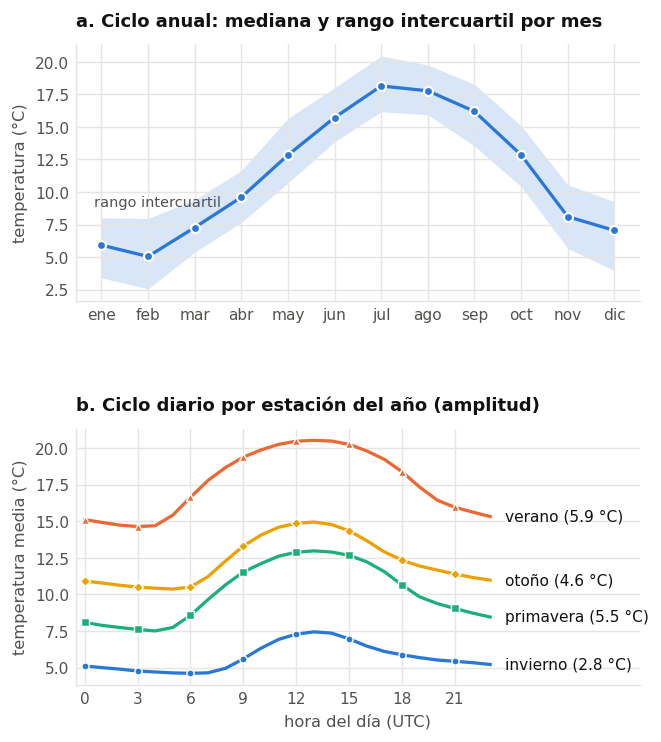

amplitud diaria (°C): {'invierno': 2.83, 'primavera': 5.47, 'verano': 5.89, 'otoño': 4.58}


In [3]:
ESTACIONES = {12: "invierno", 1: "invierno", 2: "invierno", 3: "primavera", 4: "primavera", 5: "primavera",
              6: "verano", 7: "verano", 8: "verano", 9: "otoño", 10: "otoño", 11: "otoño"}
COLOR_ESTACION = {"invierno": AZUL, "primavera": AGUA, "verano": NARANJA, "otoño": AMARILLO}
MARCA_ESTACION = {"invierno": "o", "primavera": "s", "verano": "^", "otoño": "D"}

por_mes = t.groupby(t.index.month).quantile([0.25, 0.5, 0.75]).unstack()
perfil = (t.groupby([t.index.month.map(ESTACIONES), t.index.hour]).mean().unstack(0)
            [["invierno", "primavera", "verano", "otoño"]])

# Los dos paneles van uno sobre otro para que la figura quepa en una columna del informe.
fig, (a1, a2) = plt.subplots(2, 1, figsize=(5.6, 6.4), gridspec_kw={"hspace": 0.5})
meses = por_mes.index
a1.fill_between(meses, por_mes[0.25], por_mes[0.75], color=AZUL, alpha=0.18, linewidth=0)
a1.plot(meses, por_mes[0.5], color=AZUL, marker="o", markersize=5, markeredgecolor="white",
        markeredgewidth=1.2)
a1.set_xticks(range(1, 13), ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct",
                             "nov", "dic"])
a1.set_ylabel("temperatura (°C)")
a1.set_title("a. Ciclo anual: mediana y rango intercuartil por mes")
a1.annotate("rango intercuartil", (1, por_mes.loc[1, 0.75]), xytext=(-4, 5), textcoords="offset points",
            fontsize=8, color=TINTA_SUAVE, va="bottom")

for est in perfil.columns:
    a2.plot(perfil.index, perfil[est], color=COLOR_ESTACION[est], marker=MARCA_ESTACION[est], markersize=4,
            markevery=3, markeredgecolor="white", markeredgewidth=0.8)
    amplitud = perfil[est].max() - perfil[est].min()
    a2.annotate(f"{est} ({amplitud:.1f} °C)", (23, perfil[est].iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=8.5, color=TINTA)
a2.set_xticks(range(0, 24, 3))
a2.set_xlim(-0.5, 31.5)
a2.set_xlabel("hora del día (UTC)")
a2.set_ylabel("temperatura media (°C)")
a2.set_title("b. Ciclo diario por estación del año (amplitud)")
fig.savefig(RUTA_RES / "fig_p1_ciclos.png")
plt.show()
print("amplitud diaria (°C):", (perfil.max() - perfil.min()).round(2).to_dict())

## 2. Memoria de la serie y dificultad de cada horizonte

Arriba, la autocorrelación hasta 8 días con la ventana de entrada escogida (168 h) sombreada. Abajo, el error de la
persistencia ("la temperatura dentro de *k* horas será la de ahora") según el horizonte, que muestra por qué 24 h no es
un problema trivial aunque el error vuelva a bajar en ese punto.

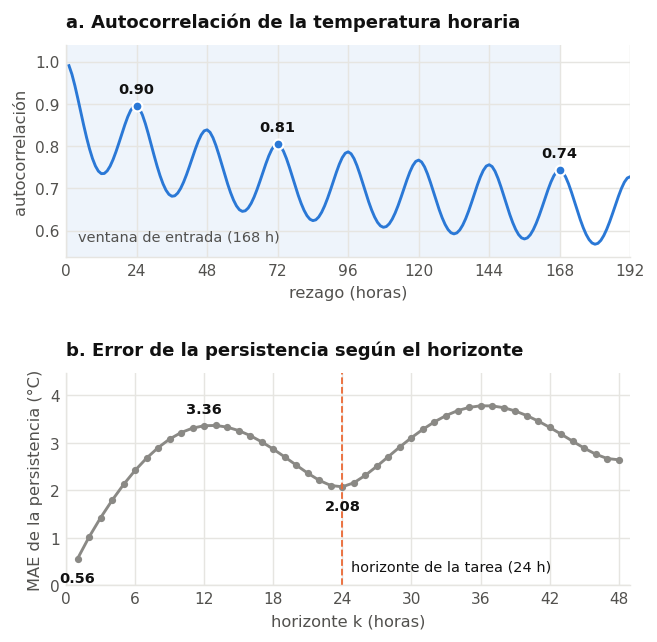

ACF en 24/72/168 h: [0.896 0.805 0.743] | persistencia 1/12/24 h: [0.56 3.36 2.08]


In [4]:
L_FINAL = metricas["tarea"]["entrada_h"]
rezagos = np.arange(1, 24 * 8 + 1)
acf = np.array([t.autocorr(lag=k) for k in rezagos])
horizontes = np.arange(1, 49)
mae_pers = np.array([(t.shift(-k) - t).abs().mean() for k in horizontes])

fig, (a1, a2) = plt.subplots(2, 1, figsize=(5.6, 5.4), gridspec_kw={"hspace": 0.55})
a1.axvspan(0, L_FINAL, color=AZUL, alpha=0.08, linewidth=0)
a1.plot(rezagos, acf, color=AZUL, linewidth=1.6)
for k in (24, 72, 168):
    a1.scatter(k, acf[k - 1], s=30, color=AZUL, edgecolor="white", linewidth=1.2, zorder=3)
    a1.annotate(f"{acf[k - 1]:.2f}", (k, acf[k - 1]), xytext=(0, 7), textcoords="offset points",
                ha="center", fontsize=8, fontweight="semibold")
a1.annotate(f"ventana de entrada ({L_FINAL} h)", (4, acf.min()), fontsize=8, color=TINTA_SUAVE, va="bottom")
a1.set_xticks(range(0, 24 * 8 + 1, 24))
a1.set_xlim(0, 24 * 8)
a1.set_ylim(acf.min() - 0.03, 1.04)
a1.set_xlabel("rezago (horas)")
a1.set_ylabel("autocorrelación")
a1.set_title("a. Autocorrelación de la temperatura horaria")

a2.plot(horizontes, mae_pers, color=GRIS, linewidth=1.6, marker="o", markersize=3)
a2.axvline(24, color=NARANJA, linewidth=1.0, linestyle="--")
a2.annotate("horizonte de la tarea (24 h)", (24, 0.25), xytext=(5, 0), textcoords="offset points",
            fontsize=8, color=TINTA, va="bottom")
for k in (1, 12, 24):
    a2.annotate(f"{mae_pers[k - 1]:.2f}", (k, mae_pers[k - 1]), xytext=(0, -13 if k != 12 else 7),
                textcoords="offset points", ha="center", fontsize=8, fontweight="semibold")
a2.set_xticks(range(0, 49, 6))
a2.set_xlim(0, 49)
a2.set_ylim(0, mae_pers.max() * 1.18)
a2.set_xlabel("horizonte k (horas)")
a2.set_ylabel("MAE de la persistencia (°C)")
a2.set_title("b. Error de la persistencia según el horizonte")
fig.savefig(RUTA_RES / "fig_p1_memoria.png")
plt.show()
print("ACF en 24/72/168 h:", acf[[23, 71, 167]].round(3), "| persistencia 1/12/24 h:", mae_pers[[0, 11, 23]].round(2))

## 3. Partición cronológica

Cada conjunto lleva su nombre y sus fechas encima del tramo que le corresponde. Nada se baraja: el test es el 30 % final.

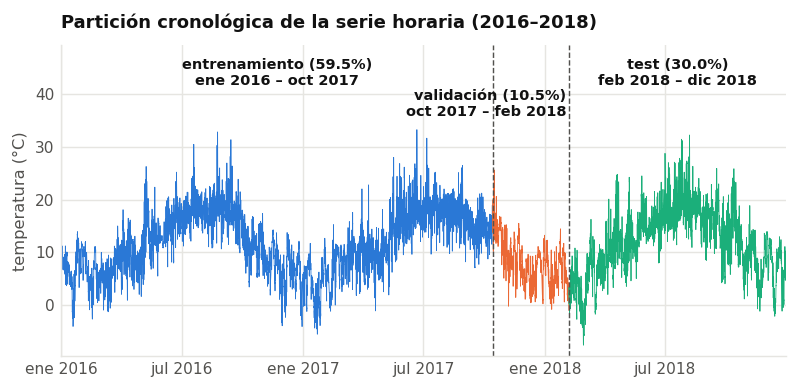

In [5]:
i_val, i_test = config["i_val"], config["i_test"]
tramos = [("entrenamiento", t.iloc[:i_val], AZUL), ("validación", t.iloc[i_val:i_test], NARANJA),
          ("test", t.iloc[i_test:], AGUA)]

MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]


def mes_anio(fecha):
    return f"{MESES[fecha.month - 1]} {fecha.year}"


fig, a = plt.subplots(figsize=(7.2, 3.1))
tope = t.max() + 3
# La validación es un tramo angosto: su rótulo va un renglón más abajo y pegado a la derecha de su
# tramo para no chocar con el del test.
altura = {"entrenamiento": tope + 5, "validación": tope - 1, "test": tope + 5}
for nombre, parte, color in tramos:
    a.plot(parte.index, parte.values, color=color, linewidth=0.45)
    centro = parte.index[0] + (parte.index[-1] - parte.index[0]) / 2
    x, alinear = (parte.index[-1] - pd.Timedelta(days=4), "right") if nombre == "validación" else (centro, "center")
    a.annotate(f"{nombre} ({len(parte) / len(t):.1%})\n{mes_anio(parte.index[0])} – {mes_anio(parte.index[-1])}",
               (x, altura[nombre]), ha=alinear, va="bottom", fontsize=8, color=TINTA, fontweight="semibold")
for corte in (t.index[i_val], t.index[i_test]):
    a.axvline(corte, color=TINTA_SUAVE, linewidth=0.8, linestyle="--")
a.set_ylim(t.min() - 2, tope + 13)
a.set_ylabel("temperatura (°C)")
marcas = pd.date_range("2016-01-01", "2018-12-01", freq="6MS")
a.set_xticks(marcas, [mes_anio(m) for m in marcas])
a.set_xlim(t.index[0], t.index[-1])
a.set_title("Partición cronológica de la serie horaria (2016–2018)")
fig.savefig(RUTA_RES / "fig_p1_particion.png")
plt.show()

## 4. Búsqueda de hiperparámetros

Una fila por corrida, agrupadas por etapa. El punto lleno es el MAE de validación (con el que se decide) y el hueco, el de
entrenamiento: la distancia entre los dos es el sobreajuste. La corrida ganadora de cada etapa va resaltada.

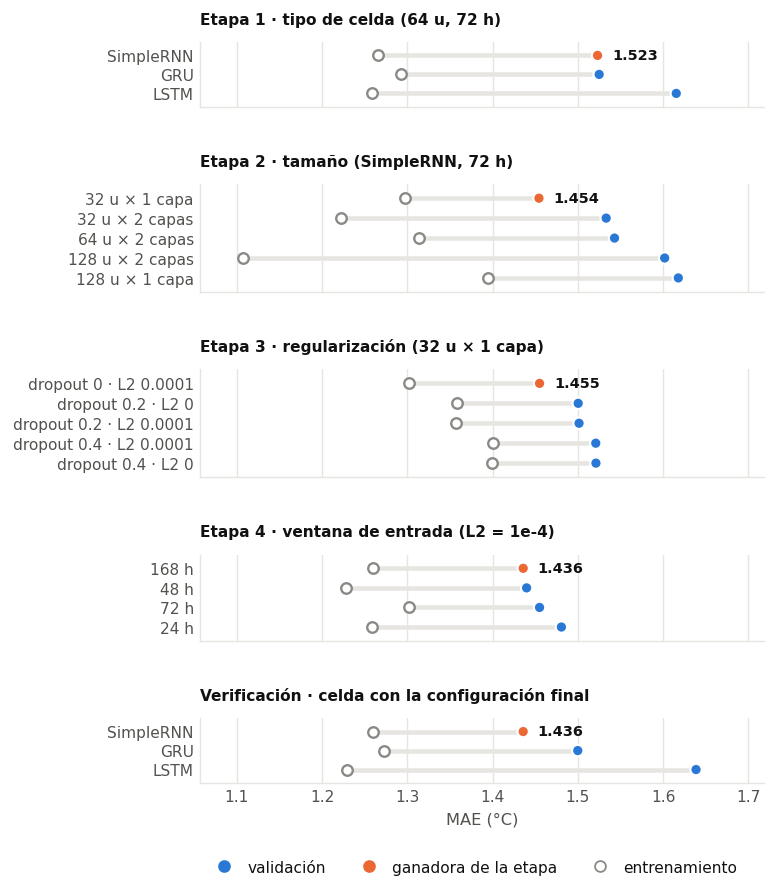

In [6]:
NOMBRE_ETAPA = {"1_celda": "Etapa 1 · tipo de celda (64 u, 72 h)", "2_tamano": "Etapa 2 · tamaño (SimpleRNN, 72 h)",
                "3_regularizacion": "Etapa 3 · regularización (32 u × 1 capa)",
                "4_ventana": "Etapa 4 · ventana de entrada (L2 = 1e-4)",
                "5_verificacion": "Verificación · celda con la configuración final"}


def etiqueta(fila):
    etapa = fila.etapa
    if etapa in ("1_celda", "5_verificacion"):
        return fila.celda
    if etapa == "2_tamano":
        return f"{fila.unidades} u × {fila.capas} capa{'s' if fila.capas > 1 else ''}"
    if etapa == "3_regularizacion":
        return f"dropout {fila.dropout:g} · L2 {fila.l2:g}"
    return f"{fila.L} h"


e = experimentos.copy()
# Dos corridas sirven en dos etapas y el CSV las guarda una sola vez: 72 h con L2 = 1e-4 salió de la
# etapa 3 y la SimpleRNN de la verificación es la ganadora de la etapa 4. Se copian para que cada
# panel muestre la comparación completa.
base_72 = e[(e.etapa == "3_regularizacion") & (e.dropout == 0) & (e.l2 > 0)].assign(etapa="4_ventana")
final = e[e.etapa == "4_ventana"].nsmallest(1, "mae_valid").assign(etapa="5_verificacion")
e = pd.concat([e, base_72, final], ignore_index=True)
e["etiqueta"] = e.apply(etiqueta, axis=1)
etapas = [x for x in NOMBRE_ETAPA if x in set(e.etapa)]
filas = [len(e[e.etapa == x]) for x in etapas]

fig = plt.figure(figsize=(5.6, 7.4))
rejilla = fig.add_gridspec(len(etapas), 1, height_ratios=filas, hspace=0.9)
lim = (e[["mae_entre", "mae_valid"]].min().min() - 0.05, e[["mae_entre", "mae_valid"]].max().max() + 0.08)
for k, etapa in enumerate(etapas):
    a = fig.add_subplot(rejilla[k])
    bloque = e[e.etapa == etapa].sort_values("mae_valid", ascending=False)
    y = np.arange(len(bloque))
    ganadora = bloque.mae_valid.idxmin()
    a.hlines(y, bloque.mae_entre, bloque.mae_valid, color=MALLA, linewidth=2.5, zorder=1)
    a.scatter(bloque.mae_entre, y, s=34, facecolor="white", edgecolor=GRIS, linewidth=1.3, zorder=2)
    colores = [NARANJA if i == ganadora else AZUL for i in bloque.index]
    a.scatter(bloque.mae_valid, y, s=40, color=colores, edgecolor="white", linewidth=1.2, zorder=3)
    g = bloque.loc[ganadora]
    a.annotate(f"{g.mae_valid:.3f}", (g.mae_valid, list(bloque.index).index(ganadora)), xytext=(8, 0),
               textcoords="offset points", va="center", fontsize=8, fontweight="semibold")
    a.set_yticks(y, bloque.etiqueta)
    a.set_ylim(-0.7, len(bloque) - 0.3)
    a.set_xlim(*lim)
    a.grid(axis="y", visible=False)
    a.set_title(NOMBRE_ETAPA[etapa], fontsize=8.5)
    if k < len(etapas) - 1:
        a.set_xticklabels([])
    else:
        a.set_xlabel("MAE (°C)")

leyenda_abajo(fig, [
    Line2D([], [], color=AZUL, marker="o", linestyle="none", markersize=6, label="validación"),
    Line2D([], [], color=NARANJA, marker="o", linestyle="none", markersize=6, label="ganadora de la etapa"),
    Line2D([], [], markerfacecolor="white", markeredgecolor=GRIS, marker="o", linestyle="none", markersize=6,
           label="entrenamiento"),
], y=0.0)
fig.savefig(RUTA_RES / "fig_p1_busqueda.png")
plt.show()

## 5. Error en test por horizonte

La RNN contra las tres líneas base sobre las mismas 7 701 ventanas de test, sin las horas imputadas. El nombre de cada
serie va al final de su curva.

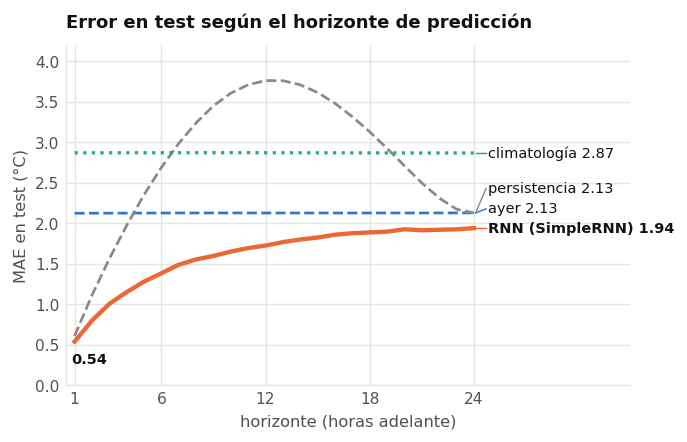

{'RNN (SimpleRNN)': 1.602, 'ayer': 2.128, 'persistencia': 2.785, 'climatología': 2.871}


In [7]:
SERIES = [("RNN", "RNN (SimpleRNN)", NARANJA, "-", 2.4), ("ayer", "ayer", AZUL, "--", 1.5),
          ("persistencia", "persistencia", GRIS, "--", 1.5), ("climatologia", "climatología", AGUA, ":", 1.8)]
hs = np.arange(1, len(metricas["test"]["RNN"]["MAE_por_horizonte"]) + 1)

fig, a = plt.subplots(figsize=(5.6, 3.4))
finales = {}
for clave, nombre, color, estilo, grosor in SERIES:
    valores = np.array(metricas["test"][clave]["MAE_por_horizonte"])
    a.plot(hs, valores, color=color, linestyle=estilo, linewidth=grosor)
    finales[nombre] = (valores[-1], color)

# Las etiquetas del final se separan un poco en vertical cuando dos curvas terminan casi juntas.
ocupadas = []
for nombre, (valor, color) in sorted(finales.items(), key=lambda x: x[1][0]):
    y = valor
    while any(abs(y - o) < 0.2 for o in ocupadas):
        y += 0.05
    ocupadas.append(y)
    a.annotate(f"{nombre} {valor:.2f}", (hs[-1], valor), xytext=(hs[-1] + 0.8, y), textcoords="data",
               va="center", fontsize=8, color=TINTA, fontweight="semibold" if nombre.startswith("RNN") else None)
    a.plot([hs[-1] + 0.1, hs[-1] + 0.7], [valor, y], color=color, linewidth=0.8)

rnn = metricas["test"]["RNN"]["MAE_por_horizonte"]
a.annotate(f"{rnn[0]:.2f}", (1, rnn[0]), xytext=(-2, -12), textcoords="offset points", fontsize=8,
           fontweight="semibold")
a.set_xticks([1, 6, 12, 18, 24])
a.set_xlim(0.5, 33)
a.set_ylim(0, 4.2)
a.set_xlabel("horizonte (horas adelante)")
a.set_ylabel("MAE en test (°C)")
a.set_title("Error en test según el horizonte de predicción")
fig.savefig(RUTA_RES / "fig_p1_horizonte.png")
plt.show()
print({n: round(metricas["test"][c]["MAE"], 3) for c, n, *_ in SERIES})

In [8]:
print("figuras en results/punto1/:\n")
for p in sorted(RUTA_RES.glob("fig_p1_*.png")):
    print(f"  {p.name:<26} {p.stat().st_size / 1024:7.1f} KB")

figuras en results/punto1/:

  fig_p1_busqueda.png          213.7 KB
  fig_p1_ciclos.png            225.9 KB
  fig_p1_horizonte.png         109.2 KB
  fig_p1_memoria.png           187.9 KB
  fig_p1_particion.png         196.0 KB
